In [1]:
import kagglehub
import pandas as pd
import numpy as np
import os
import re
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


In [2]:
path = kagglehub.dataset_download("yufengdev/bbc-fulltext-and-category")

print("Dataset downloaded to:")
print(path)

print("\nFiles in dataset:")
print(os.listdir(path))


100%|██████████| 1.83M/1.83M [00:00<00:00, 3.10MB/s]

Extracting files...


Dataset downloaded to:
/root/.cache/kagglehub/datasets/yufengdev/bbc-fulltext-and-category/versions/2

Files in dataset:
['bbc-text.csv']


In [3]:
csv_files = []

for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".csv"):
            csv_files.append(os.path.join(root, file))

print(csv_files)


['/root/.cache/kagglehub/datasets/yufengdev/bbc-fulltext-and-category/versions/2/bbc-text.csv']


In [4]:
df = pd.read_csv(csv_files[0])
df.head()


,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


In [5]:
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())


Shape of dataset: (2225, 2)

Column names:
['category', 'text']


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  2225 non-null   object
 1   text      2225 non-null   object
dtypes: object(2)
memory usage: 34.9+ KB


In [7]:
print("Missing values:")
print(df.isnull().sum())


Missing values:
category    0
text        0
dtype: int64


In [8]:
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 99


In [16]:
df = df.dropna()
df = df.drop_duplicates()

print("Shape after cleaning:", df.shape)


Shape after cleaning: (2126, 2)


In [12]:
print(df.columns)


Index(['category', 'text'], dtype='object')


In [14]:
# Rename columns
text_candidates = ['text', 'content', 'article', 'news']
label_candidates = ['category', 'label', 'class', 'topic']

text_col = next((col for col in df.columns if col.lower() in text_candidates), None)
label_col = next((col for col in df.columns if col.lower() in label_candidates), None)

print("Text column:", text_col)
print("Target column:", label_col)


Text column: text
Target column: category


In [15]:
df = df[[text_col, label_col]].copy()
df.columns = ['text', 'category']

df.head()


,text,category
0,tv future in the hands of viewers with home th...,tech
1,worldcom boss left books alone former worldc...,business
2,tigers wary of farrell gamble leicester say ...,sport
3,yeading face newcastle in fa cup premiership s...,sport
4,ocean s twelve raids box office ocean s twelve...,entertainment


In [17]:
df['category'].value_counts()


,count
category,
sport,504
business,503
politics,403
entertainment,369
tech,347


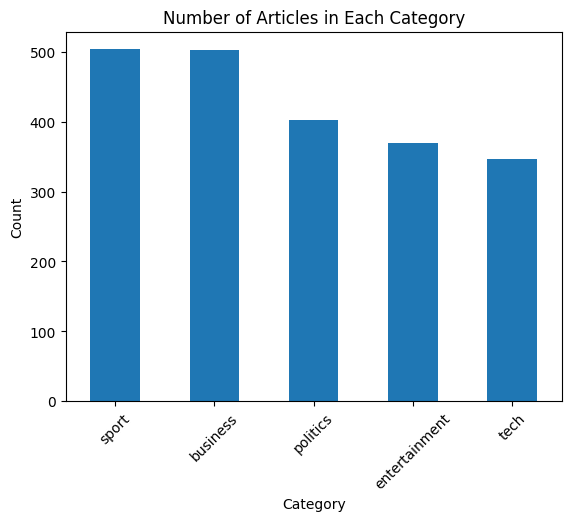

In [18]:
df['category'].value_counts().plot(kind='bar')
plt.title('Number of Articles in Each Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


In [19]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


In [20]:
df['clean_text'] = df['text'].apply(clean_text)

df[['text', 'clean_text']].head()


,text,clean_text
0,tv future in the hands of viewers with home th...,tv future in the hands of viewers with home th...
1,worldcom boss left books alone former worldc...,worldcom boss left books alone former worldcom...
2,tigers wary of farrell gamble leicester say ...,tigers wary of farrell gamble leicester say th...
3,yeading face newcastle in fa cup premiership s...,yeading face newcastle in fa cup premiership s...
4,ocean s twelve raids box office ocean s twelve...,ocean s twelve raids box office ocean s twelve...


In [21]:
X = df['clean_text']
y = df['category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 1700
Testing samples: 426


In [22]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training feature shape:", X_train_tfidf.shape)
print("Testing feature shape:", X_test_tfidf.shape)


Training feature shape: (1700, 5000)
Testing feature shape: (426, 5000)


In [23]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)


LogisticRegression(max_iter=1000)

In [24]:
y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


Accuracy: 0.9671361502347418


In [25]:
print(classification_report(y_test, y_pred))


               precision    recall  f1-score   support

     business       0.91      0.97      0.94       101
entertainment       1.00      0.95      0.97        74
     politics       0.99      0.96      0.97        81
        sport       0.99      1.00      1.00       101
         tech       0.97      0.94      0.96        69

     accuracy                           0.97       426
    macro avg       0.97      0.96      0.97       426
 weighted avg       0.97      0.97      0.97       426



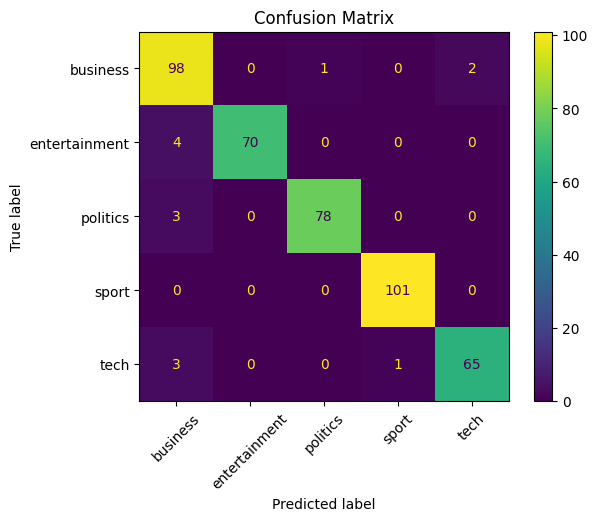

In [26]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(xticks_rotation=45)
plt.title('Confusion Matrix')
plt.show()


In [27]:
sample_news = [
    "The team won the championship after an exciting final match."
]

sample_clean = [clean_text(text) for text in sample_news]
sample_tfidf = tfidf.transform(sample_clean)

prediction = model.predict(sample_tfidf)

print("Predicted category:", prediction[0])


Predicted category: sport
